## DataFlair Stock Price Prediction Project

##### Load Data > Clean Data > Visualize Data > Select Features > Train Model > Predict Prices > Evaluate Accuracy >

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [28]:
df=pd.read_csv(r"C:\Users\lenovo\Desktop\Stock_price_prediction\stock_data.csv")
df

,Date,Open,High,Low,Close,Volume,OpenInt,Stock
0,1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,0,AAPL
1,1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,0,AAPL
2,1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,0,AAPL
3,1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,0,AAPL
4,1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,0,AAPL
...,...,...,...,...,...,...,...,...
19581,2017-11-06,178.56000,180.45000,178.31000,180.17000,13275578,0,FB
19582,2017-11-07,180.50000,180.74800,179.40300,180.25000,12903836,0,FB
19583,2017-11-08,179.79000,180.35000,179.11000,179.56000,10467606,0,FB
19584,2017-11-09,178.31000,179.40000,177.09000,179.30000,12602188,0,FB


## Check Available Companies

In [29]:
df['Stock'].unique()

array(['AAPL', 'TSLA', 'MSFT', 'FB'], dtype=object)

In [30]:
apple = df[df['Stock'] == 'AAPL']

In [31]:
apple.head()

,Date,Open,High,Low,Close,Volume,OpenInt,Stock
0,1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,0,AAPL
1,1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,0,AAPL
2,1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,0,AAPL
3,1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,0,AAPL
4,1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,0,AAPL


In [32]:
apple.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8364 entries, 0 to 8363
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     8364 non-null   object 
 1   Open     8364 non-null   float64
 2   High     8364 non-null   float64
 3   Low      8364 non-null   float64
 4   Close    8364 non-null   float64
 5   Volume   8364 non-null   int64  
 6   OpenInt  8364 non-null   int64  
 7   Stock    8364 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 588.1+ KB


In [33]:
apple.isnull().sum()

Date       0
Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
Stock      0
dtype: int64

## Convert Date Column

In [34]:
apple['Date'] = pd.to_datetime(apple['Date'])

C:\Users\lenovo\AppData\Local\Temp\ipykernel_19320\947707937.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple['Date'] = pd.to_datetime(apple['Date'])


## Set Date as Index

In [35]:
apple.set_index('Date', inplace=True)

## Visualize Closing Price

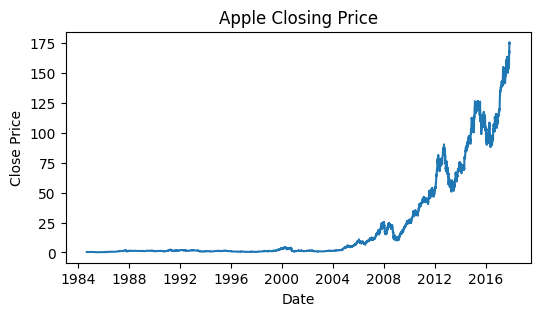

In [36]:
plt.figure(figsize=(6,3))
plt.plot(apple['Close'])
plt.title("Apple Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

## Select Features

In [37]:
features = apple[['Open', 'High', 'Low', 'Volume']]

In [38]:
target = apple['Close']

## Train-Test Split

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

## Train Linear Regression Model

In [41]:
from sklearn.linear_model import LinearRegression

In [42]:
model = LinearRegression()

In [43]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Predict Prices

In [44]:
predictions = model.predict(X_test)

## Check Accuracy

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [46]:
mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 0.0993868164091462


## Plot Real vs Predicted

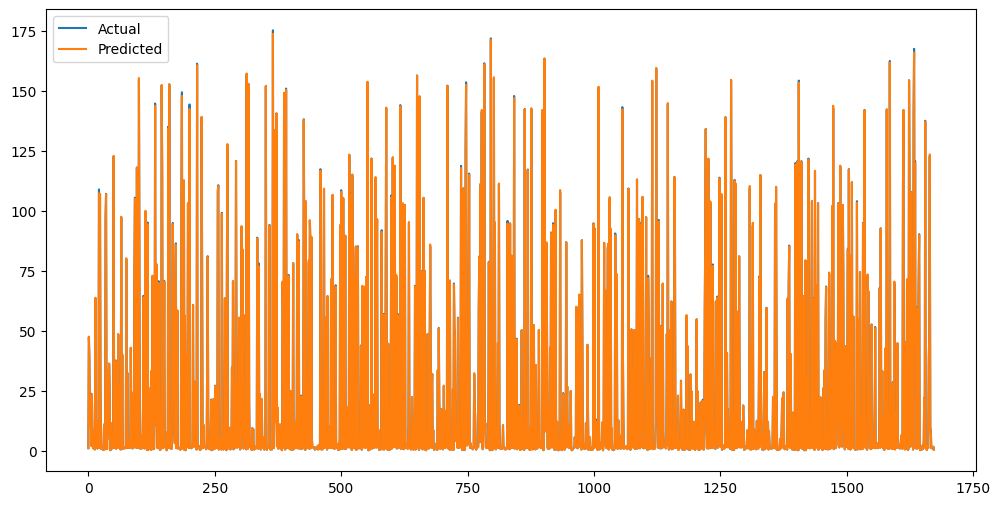

In [47]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')

plt.legend()
plt.show()

## Calculate RMSE

In [48]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RMSE:", rmse)

RMSE: 0.23308599665376648


## Final Prediction Example

In [49]:
print(predictions[:10])

[ 1.11448116 47.61077278 38.79056486 15.58986924  9.86276854 23.29739852
  2.06033166 23.49868331  9.46676672  1.52324887]


### Compare Actual vs Predicted Prices

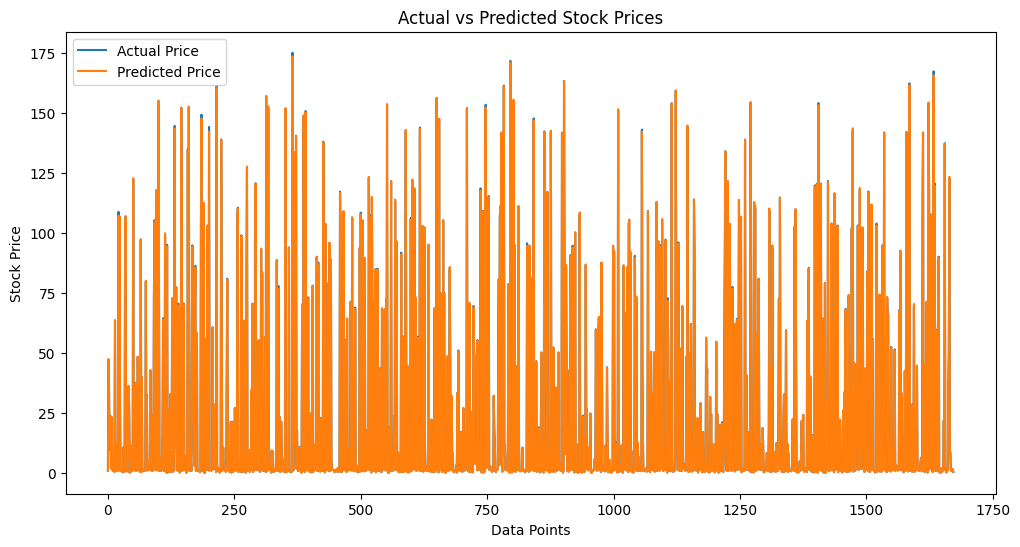

In [58]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual Price')
plt.plot(predictions, label='Predicted Price')

plt.xlabel("Data Points")
plt.ylabel("Stock Price")
plt.title("Actual vs Predicted Stock Prices")

plt.legend()
plt.show()

### Calculate R² Score

In [59]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: 0.9999633074626231


### Create Prediction DataFrame

In [60]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

print(results.head())

    Actual  Predicted
0   1.1206   1.114481
1  47.3560  47.610773
2  38.5440  38.790565
3  15.6490  15.589869
4   9.7380   9.862769


### Save Predictions

In [61]:
results.to_csv("stock_predictions.csv", index=False)

### Add Future Prediction Logic

In [62]:
future_input = [[180, 182, 178, 1200000]]

future_prediction = model.predict(future_input)

print("Future Predicted Price:", future_prediction)

Future Predicted Price: [180.10734362]


C:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Make Better Visualization

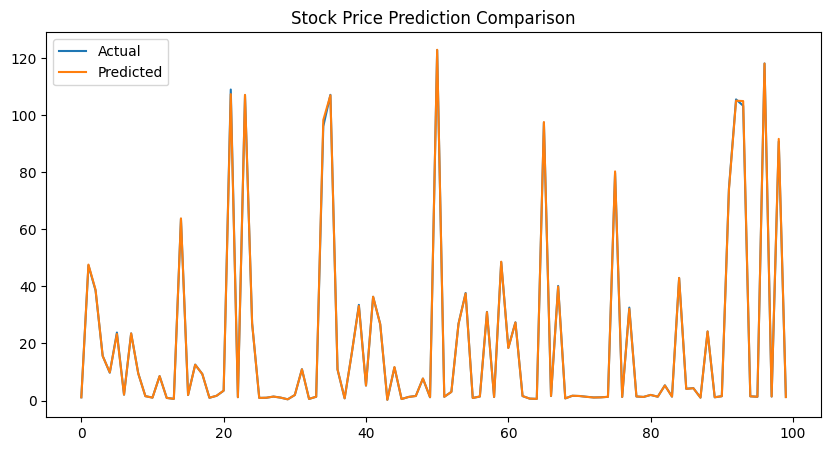

In [64]:
plt.figure(figsize=(10,5))

plt.plot(results['Actual'][:100], label='Actual')
plt.plot(results['Predicted'][:100], label='Predicted')

plt.title("Stock Price Prediction Comparison")
plt.legend()

plt.show()

In [65]:
import joblib

joblib.dump(model, 'stock_model.pkl')

['stock_model.pkl']